### Decision Tree Regression Task

##### 기온 및 강수량 별 모기 비율 예측

- date: 년-월-일
- mosquito_Indicator: 모기 비율
- rain(mm): 일 강수량
- mean_T(℃): 일 평균 기온
- min_T(℃): 일 최저 기온
- max_T(℃): 일 최고 기온

In [3]:
import pandas as pd

mos_df = pd.read_csv('./datasets/korea_mosquito.csv')
mos_df

,date,mosquito_Indicator,rain(mm),mean_T(℃),min_T(℃),max_T(℃)
0,2016-05-01,254.4,0.0,18.8,12.2,26.0
1,2016-05-02,273.5,16.5,21.1,16.5,28.4
2,2016-05-03,304.0,27.0,12.9,8.9,17.6
3,2016-05-04,256.2,0.0,15.7,10.2,20.6
4,2016-05-05,243.8,7.5,18.9,10.2,26.9
...,...,...,...,...,...,...
1337,2019-12-27,5.5,0.0,-1.7,-4.6,2.6
1338,2019-12-28,5.5,0.0,1.1,-3.6,6.1
1339,2019-12-29,5.5,1.4,3.8,1.1,6.2
1340,2019-12-30,5.5,0.4,2.7,-5.7,6.8


In [4]:
mos_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mosquito_Indicator,1342.0,251.991803,295.871336,0.0,5.5,91.9,480.400,1000.0
rain(mm),1342.0,3.539866,13.868106,0.0,0.0,0.0,0.400,144.5
mean_T(℃),1342.0,14.166021,10.943990,-14.8,4.5,16.5,23.300,33.7
min_T(℃),1342.0,10.005663,11.109489,-17.8,0.3,11.5,19.500,30.3
max_T(℃),1342.0,19.096870,11.063394,-10.7,9.3,21.9,28.175,39.6


In [5]:
mos_df.isna().sum()

date                  0
mosquito_Indicator    0
rain(mm)              0
mean_T(℃)             0
min_T(℃)              0
max_T(℃)              0
dtype: int64

In [6]:
mos_df.duplicated().sum()

np.int64(47)

In [7]:
mos_df = mos_df.drop_duplicates()
mos_df = mos_df.reset_index(drop=True)
mos_df

,date,mosquito_Indicator,rain(mm),mean_T(℃),min_T(℃),max_T(℃)
0,2016-05-01,254.4,0.0,18.8,12.2,26.0
1,2016-05-02,273.5,16.5,21.1,16.5,28.4
2,2016-05-03,304.0,27.0,12.9,8.9,17.6
3,2016-05-04,256.2,0.0,15.7,10.2,20.6
4,2016-05-05,243.8,7.5,18.9,10.2,26.9
...,...,...,...,...,...,...
1290,2019-12-27,5.5,0.0,-1.7,-4.6,2.6
1291,2019-12-28,5.5,0.0,1.1,-3.6,6.1
1292,2019-12-29,5.5,1.4,3.8,1.1,6.2
1293,2019-12-30,5.5,0.4,2.7,-5.7,6.8


In [8]:
mos_df['month'] = pd.to_datetime(mos_df.date).dt.month
mos_df

,date,mosquito_Indicator,rain(mm),mean_T(℃),min_T(℃),max_T(℃),month
0,2016-05-01,254.4,0.0,18.8,12.2,26.0,5
1,2016-05-02,273.5,16.5,21.1,16.5,28.4,5
2,2016-05-03,304.0,27.0,12.9,8.9,17.6,5
3,2016-05-04,256.2,0.0,15.7,10.2,20.6,5
4,2016-05-05,243.8,7.5,18.9,10.2,26.9,5
...,...,...,...,...,...,...,...
1290,2019-12-27,5.5,0.0,-1.7,-4.6,2.6,12
1291,2019-12-28,5.5,0.0,1.1,-3.6,6.1,12
1292,2019-12-29,5.5,1.4,3.8,1.1,6.2,12
1293,2019-12-30,5.5,0.4,2.7,-5.7,6.8,12


In [9]:
mos_df = mos_df.drop(columns='date', axis=1)
mos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mosquito_Indicator  1295 non-null   float64
 1   rain(mm)            1295 non-null   float64
 2   mean_T(℃)           1295 non-null   float64
 3   min_T(℃)            1295 non-null   float64
 4   max_T(℃)            1295 non-null   float64
 5   month               1295 non-null   int32  
dtypes: float64(5), int32(1)
memory usage: 55.8 KB


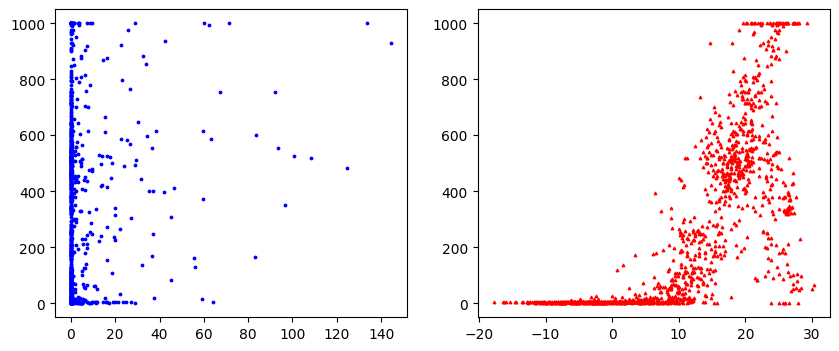

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].scatter(x='rain(mm)', y='mosquito_Indicator', data=mos_df, c='blue', s=3)
ax[1].scatter(x='min_T(℃)', y='mosquito_Indicator', data=mos_df, c='red', marker='^', s=3)
plt.show()

In [12]:
mos_df.corr()

,mosquito_Indicator,rain(mm),mean_T(℃),min_T(℃),max_T(℃),month
mosquito_Indicator,1.000000,0.186194,0.728177,0.743387,0.698576,0.124393
rain(mm),0.186194,1.000000,0.144857,0.186602,0.099130,0.030374
mean_T(℃),0.728177,0.144857,1.000000,0.990115,0.989594,0.171280
min_T(℃),0.743387,0.186602,0.990115,1.000000,0.964792,0.180820
max_T(℃),0.698576,0.099130,0.989594,0.964792,1.000000,0.150225
month,0.124393,0.030374,0.171280,0.180820,0.150225,1.000000


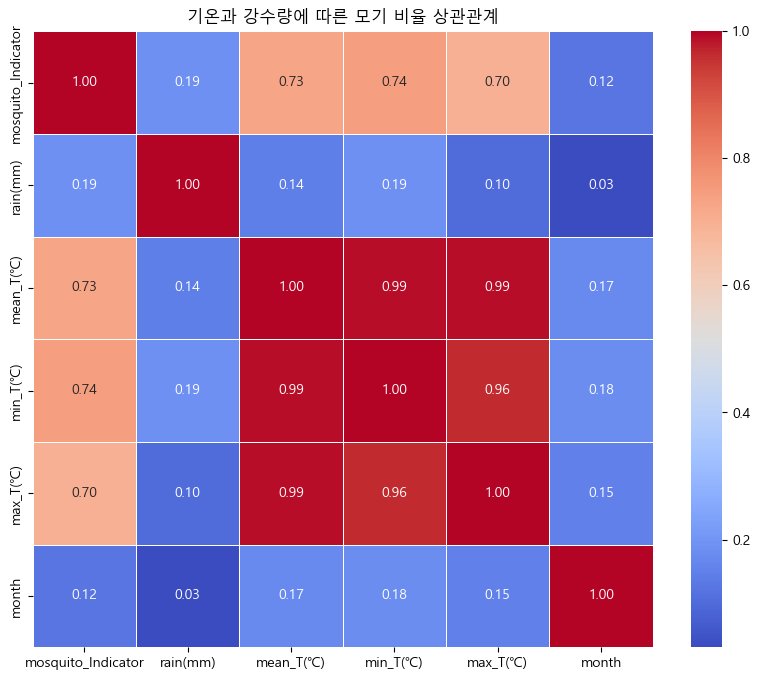

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상관계수 계산
corr = mos_df.corr()

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('기온과 강수량에 따른 모기 비율 상관관계')
plt.show()

In [14]:
pre_mos_df = mos_df[['rain(mm)', 'month', 'min_T(℃)', 'mosquito_Indicator']]
pre_mos_df

,rain(mm),month,min_T(℃),mosquito_Indicator
0,0.0,5,12.2,254.4
1,16.5,5,16.5,273.5
2,27.0,5,8.9,304.0
3,0.0,5,10.2,256.2
4,7.5,5,10.2,243.8
...,...,...,...,...
1290,0.0,12,-4.6,5.5
1291,0.0,12,-3.6,5.5
1292,1.4,12,1.1,5.5
1293,0.4,12,-5.7,5.5


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF < 5: 매우 양호 (독립성이 높음)
# VIF < 10: 수용 가능 (약간의 상관관계가 있으나 문제없음)
# VIF > 10: 위험 (다중공선성 존재, 변수 제거 또는 처리가 필요함)
# 만약 어떤 변수의 VIF가 20 ~ 30이라면, 그 변수는 빼거나 다른 것과 합쳐서 해결한다.
def feature_engineering_VIF(features):
    vif = pd.DataFrame()
    vif['vif_score'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    vif['feature'] = features.columns
    return vif

In [16]:
feature_engineering_VIF(pre_mos_df)

,vif_score,feature
0,1.112195,rain(mm)
1,1.810974,month
2,4.121410,min_T(℃)
3,3.793755,mosquito_Indicator


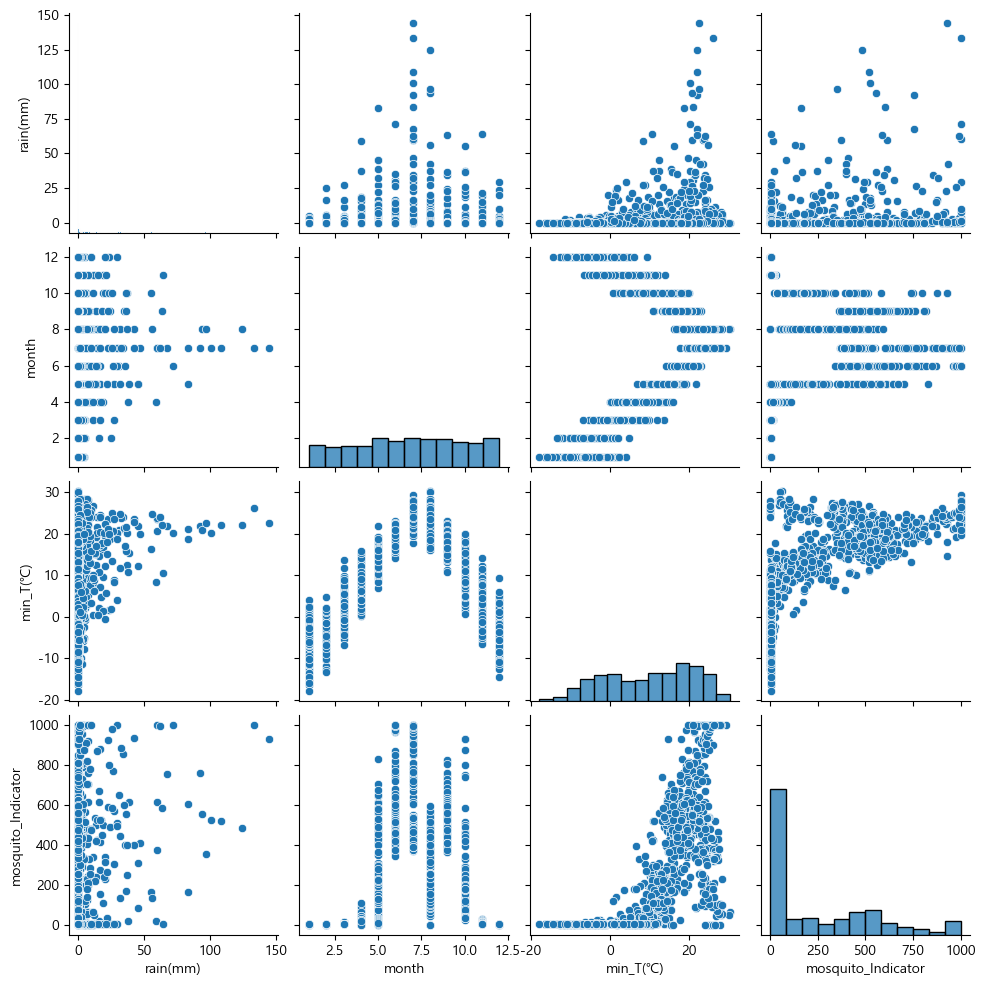

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(pre_mos_df)
plt.show()

array([[<Axes: title={'center': 'rain(mm)'}>,
        <Axes: title={'center': 'month'}>],
       [<Axes: title={'center': 'min_T(℃)'}>,
        <Axes: title={'center': 'mosquito_Indicator'}>]], dtype=object)

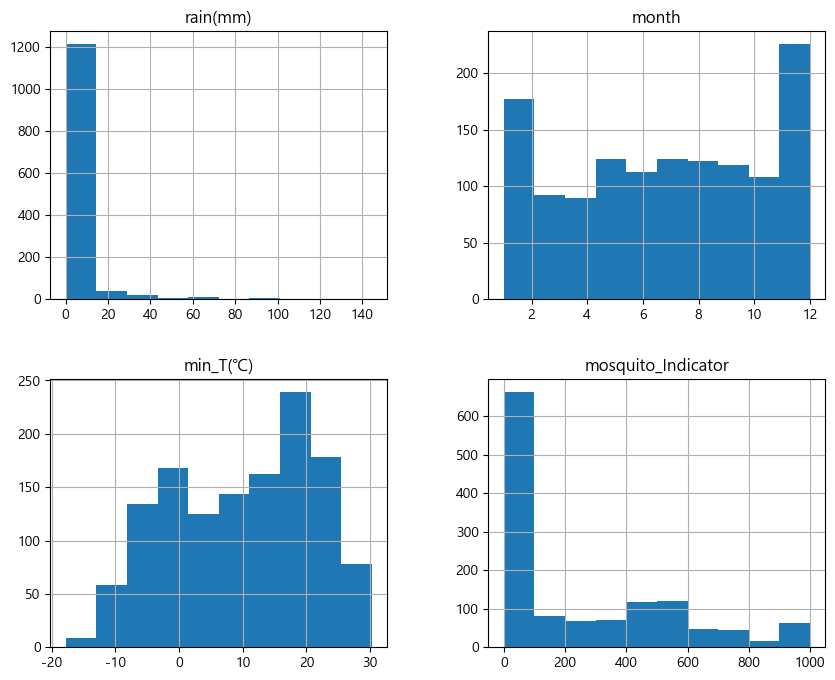

In [18]:
pre_mos_df.hist(figsize=(10, 8))

In [19]:
import numpy as np
import pandas as pd

for column in pre_mos_df.columns:
        Q1 = np.percentile(pre_mos_df[column], 25)
        Q3 = np.percentile(pre_mos_df[column], 75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        condition1 = pre_mos_df[column] >= lower_bound
        condition2 = pre_mos_df[column] <= upper_bound
        condition = condition1 & condition2
    
        pre_mos_df = pre_mos_df[condition]
        
pre_mos_df

,rain(mm),month,min_T(℃),mosquito_Indicator
0,0.0,5,12.2,254.4
3,0.0,5,10.2,256.2
6,0.0,5,10.7,243.2
7,0.0,5,11.6,249.0
8,0.0,5,16.3,249.6
...,...,...,...,...
1289,0.3,12,-2.4,5.5
1290,0.0,12,-4.6,5.5
1291,0.0,12,-3.6,5.5
1293,0.4,12,-5.7,5.5


In [20]:
pre_mos_df = pre_mos_df[pre_mos_df.mosquito_Indicator != 0].reset_index(drop=True)

In [21]:
pre_mos_df

,rain(mm),month,min_T(℃),mosquito_Indicator
0,0.0,5,12.2,254.4
1,0.0,5,10.2,256.2
2,0.0,5,10.7,243.2
3,0.0,5,11.6,249.0
4,0.0,5,16.3,249.6
...,...,...,...,...
1031,0.3,12,-2.4,5.5
1032,0.0,12,-4.6,5.5
1033,0.0,12,-3.6,5.5
1034,0.4,12,-5.7,5.5


In [22]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

features, targets = pre_mos_df.iloc[:, :-1], pre_mos_df.mosquito_Indicator

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

y_train = np.log1p(y_train)

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=4)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=1000, max_depth=8)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=4, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=4, learning_rate=0.01)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, np.expm1(prediction))

DecisionTreeRegressor
MAE: 99.1122, MSE: 29507.3459, RMSE: 171.7770, MSLE: 0.7242, RMSLE: 0.8510, R2: 0.6541
RandomForestRegressor
MAE: 75.1258, MSE: 15801.0892, RMSE: 125.7024, MSLE: 0.6302, RMSLE: 0.7938, R2: 0.8148
GradientBoostingRegressor
MAE: 83.5266, MSE: 26616.1985, RMSE: 163.1447, MSLE: 0.7613, RMSLE: 0.8725, R2: 0.6880
XGBRegressor
MAE: 71.7640, MSE: 15301.8678, RMSE: 123.7007, MSLE: 0.6159, RMSLE: 0.7848, R2: 0.8206
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 269
[LightGBM] [Info] Number of data points in the train set: 828, number of used features: 3
[LightGBM] [Info] Start training from score 3.867075
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [24]:
# 모기가 성장하는 데에 걸리는 시간: 7일
pre_mos_df['rain_7d_ago'] = pre_mos_df['rain(mm)'].shift(7)
pre_mos_df['temp_7d_ago'] = pre_mos_df['min_T(℃)'].shift(7)

In [25]:
pre_mos_df

,rain(mm),month,min_T(℃),mosquito_Indicator,rain_7d_ago,temp_7d_ago
0,0.0,5,12.2,254.4,NaN,NaN
1,0.0,5,10.2,256.2,NaN,NaN
2,0.0,5,10.7,243.2,NaN,NaN
3,0.0,5,11.6,249.0,NaN,NaN
4,0.0,5,16.3,249.6,NaN,NaN
...,...,...,...,...,...,...
1031,0.3,12,-2.4,5.5,0.0,-1.7
1032,0.0,12,-4.6,5.5,0.0,-4.5
1033,0.0,12,-3.6,5.5,0.0,-3.5
1034,0.4,12,-5.7,5.5,0.6,-5.1


In [26]:
pre_mos_df.dropna(inplace=True)
pre_mos_df.drop(['min_T(℃)'], axis=1, inplace=True)

In [27]:
feature_engineering_VIF(pre_mos_df)

,vif_score,feature
0,1.092320,rain(mm)
1,1.909391,month
2,3.378695,mosquito_Indicator
3,1.084719,rain_7d_ago
4,3.808225,temp_7d_ago


In [28]:
pre_mos_df

,rain(mm),month,mosquito_Indicator,rain_7d_ago,temp_7d_ago
7,0.5,5,258.2,0.0,12.2
8,0.0,5,277.8,0.0,10.2
9,0.0,5,256.9,0.0,10.7
10,0.0,5,275.2,0.0,11.6
11,0.0,5,309.7,0.0,16.3
...,...,...,...,...,...
1031,0.3,12,5.5,0.0,-1.7
1032,0.0,12,5.5,0.0,-4.5
1033,0.0,12,5.5,0.0,-3.5
1034,0.4,12,5.5,0.6,-5.1


In [29]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

features, targets = pre_mos_df.drop('mosquito_Indicator', axis=1), pre_mos_df.mosquito_Indicator

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=124)

scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

y_train = np.log1p(y_train)

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=4)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=1000, max_depth=6)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=4, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=4, learning_rate=0.01)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, np.expm1(prediction))

DecisionTreeRegressor
MAE: 93.3640, MSE: 29025.7770, RMSE: 170.3695, MSLE: 0.5337, RMSLE: 0.7306, R2: 0.7052
RandomForestRegressor
MAE: 80.2593, MSE: 20806.2556, RMSE: 144.2437, MSLE: 0.4688, RMSLE: 0.6847, R2: 0.7886
GradientBoostingRegressor
MAE: 91.3735, MSE: 27059.8545, RMSE: 164.4988, MSLE: 0.8322, RMSLE: 0.9123, R2: 0.7251
XGBRegressor
MAE: 79.5131, MSE: 20091.9414, RMSE: 141.7460, MSLE: 0.4758, RMSLE: 0.6898, R2: 0.7959
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 823, number of used features: 4
[LightGBM] [Info] Start training from score 3.881657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

C:\ProgramData\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [30]:
pre_mos_df['rain_3d_sum'] = pre_mos_df['rain(mm)'].rolling(window=3).sum().fillna(0)

In [31]:
pre_mos_df.drop(['rain(mm)'], axis=1, inplace=True)

In [32]:
feature_engineering_VIF(pre_mos_df)

,vif_score,feature
0,2.003240,month
1,3.379575,mosquito_Indicator
2,1.082089,rain_7d_ago
3,3.806779,temp_7d_ago
4,1.215620,rain_3d_sum


In [33]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

features, targets = pre_mos_df.drop('mosquito_Indicator', axis=1), pre_mos_df.mosquito_Indicator

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=124)

scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

y_train = np.log1p(y_train)

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=6)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=500, max_depth=6)
# 앞선 모델의 실수를 얼만큼 믿을 것인가(1.0: 높음, 0.01: 낮음)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, np.expm1(prediction))

DecisionTreeRegressor
MAE: 79.2376, MSE: 18813.0044, RMSE: 137.1605, MSLE: 0.5455, RMSLE: 0.7386, R2: 0.8089
RandomForestRegressor
MAE: 79.5151, MSE: 20088.1902, RMSE: 141.7328, MSLE: 0.4612, RMSLE: 0.6791, R2: 0.7959
GradientBoostingRegressor
MAE: 82.5618, MSE: 22299.4344, RMSE: 149.3300, MSLE: 0.7788, RMSLE: 0.8825, R2: 0.7735
XGBRegressor
MAE: 77.7163, MSE: 19195.7635, RMSE: 138.5488, MSLE: 0.5362, RMSLE: 0.7322, R2: 0.8050
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 823, number of used features: 4
[LightGBM] [Info] Start training from score 3.881657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

C:\ProgramData\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


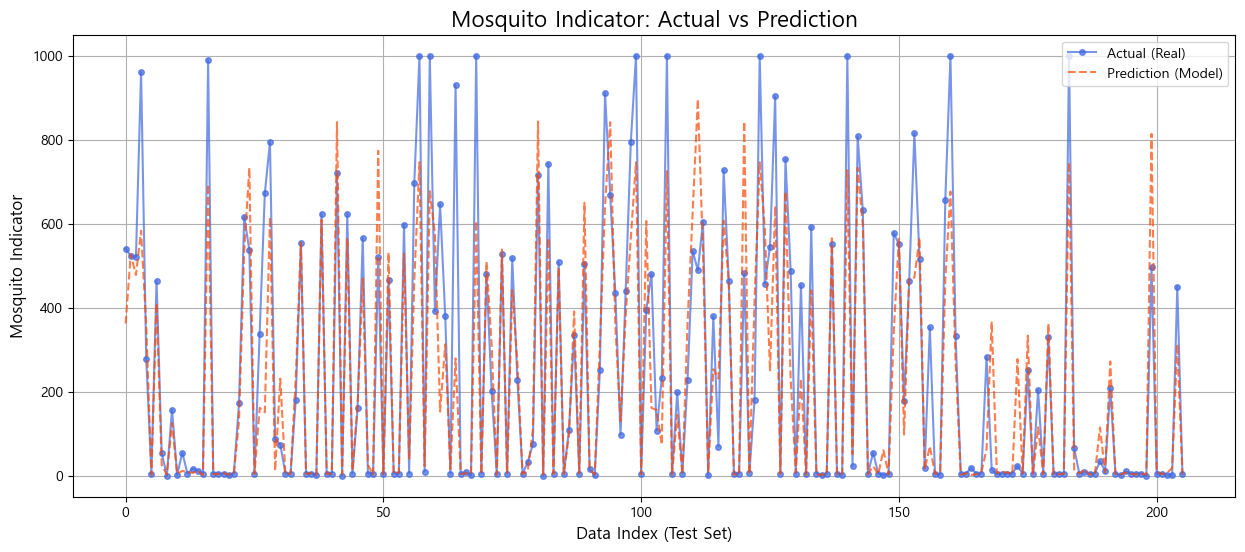

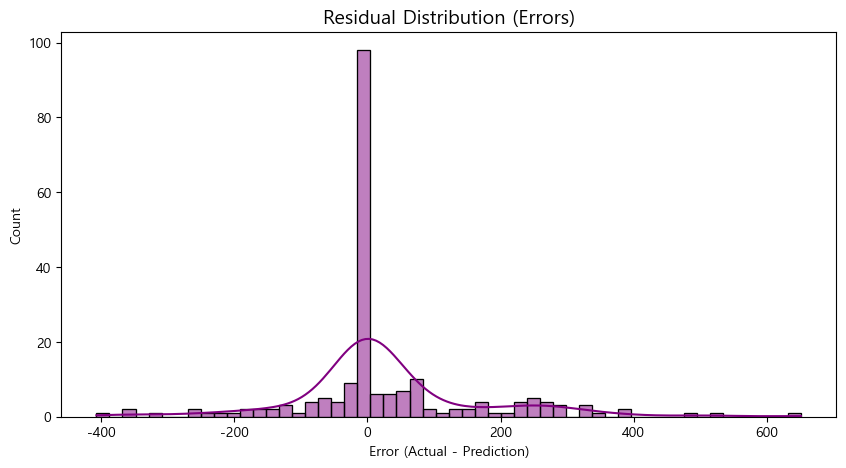

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Prediction': np.expm1(prediction) # 로그 복원
}).reset_index(drop=True)

# 오차 차이
plt.figure(figsize=(15, 6))
plt.plot(comparison_df['Actual'], label='Actual (Real)', color='royalblue', alpha=0.7, marker='o', markersize=4)
plt.plot(comparison_df['Prediction'], label='Prediction (Model)', color='orangered', alpha=0.7, linestyle='--')

plt.title('Mosquito Indicator: Actual vs Prediction', fontsize=16)
plt.xlabel('Data Index (Test Set)', fontsize=12)
plt.ylabel('Mosquito Indicator', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# 오차 분포
plt.figure(figsize=(10, 5))
sns.histplot(comparison_df['Actual'] - comparison_df['Prediction'], kde=True, color='purple')
plt.title('Residual Distribution (Errors)', fontsize=14)
plt.xlabel('Error (Actual - Prediction)')
plt.show()